# 🔋 Electric Vehicle Population — End-to-End Data Analytics & Machine Learning Project

---

**Dataset:** Washington State Electric Vehicle Population Data  
**Source:** Washington State Department of Licensing (DOL)  
**Records:** ~235,000+ EV registrations  
**Goal:** Understand EV adoption trends and predict Electric Vehicle Type (BEV vs PHEV)

---

## 📋 Project Structure
1. Imports & Setup
2. Data Loading & Understanding
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Business Insights
6. Feature Engineering
7. Machine Learning — Model Building
8. Model Evaluation & Comparison
9. Hyperparameter Tuning
10. Predictions & User Input Function

---

## 1. 📦 Imports & Configuration

In [1]:
# ─── Core Libraries ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ─── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ─── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

# ─── Style Settings ───────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'figure.facecolor': 'white'
})
PALETTE = 'viridis'

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 2. 📂 Data Loading & Understanding

In [2]:
# Load dataset — update path if needed
df = pd.read_csv('Electric_Vehicle_Population_Data.csv')

print(f'📊 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('\n📌 Column Names:')
print(df.columns.tolist())

📊 Dataset Shape: 235,692 rows × 17 columns

📌 Column Names:
['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range', 'Base MSRP', 'Legislative District', 'DOL Vehicle ID', 'Vehicle Location', 'Electric Utility', '2020 Census Tract']


In [3]:
# First look at the data
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EBXK,King,Seattle,WA,98178.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,37.0,477309682,POINT (-122.23825 47.49461),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,5YJYGDEE3L,Kitsap,Poulsbo,WA,98370.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,0.0,23.0,109705683,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303509e+10
2,KM8KRDAF5P,Kitsap,Olalla,WA,98359.0,2023,HYUNDAI,IONIQ 5,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,26.0,230390492,POINT (-122.54729 47.42602),PUGET SOUND ENERGY INC,5.303509e+10
3,5UXTA6C0XM,Kitsap,Seabeck,WA,98380.0,2021,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,30.0,0.0,35.0,267929112,POINT (-122.81585 47.64509),PUGET SOUND ENERGY INC,5.303509e+10
4,JTMAB3FV7P,Thurston,Rainier,WA,98576.0,2023,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42.0,0.0,2.0,236505139,POINT (-122.68993 46.88897),PUGET SOUND ENERGY INC,5.306701e+10


In [4]:
# Column data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235692 entries, 0 to 235691
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         235692 non-null  object 
 1   County                                             235689 non-null  object 
 2   City                                               235689 non-null  object 
 3   State                                              235692 non-null  object 
 4   Postal Code                                        235689 non-null  float64
 5   Model Year                                         235692 non-null  int64  
 6   Make                                               235692 non-null  object 
 7   Model                                              235692 non-null  object 
 8   Electric Vehicle Type                              235692 non-null  object

In [5]:
# Summary statistics for numerical columns
df.describe().round(2)

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,235689.00,235692.00,235656.00,235656.00,235198.00,235692.0,2.356890e+05
mean,98177.66,2021.41,46.26,787.27,28.88,235312720.0,5.298066e+10
std,2524.22,2.99,84.05,7177.67,14.90,67990983.7,1.521066e+09
min,1731.00,2000.00,0.00,0.00,1.00,4385.0,1.001020e+09
25%,98052.00,2020.00,0.00,0.00,17.00,205345710.0,5.303301e+10
50%,98126.00,2023.00,0.00,0.00,32.00,252279541.0,5.303303e+10
75%,98374.00,2024.00,38.00,0.00,42.00,269640094.0,5.305307e+10
max,99577.00,2025.00,337.00,845000.00,49.00,479254772.0,5.602100e+10


In [6]:
# Summary for categorical columns
df.describe(include='object')

,VIN (1-10),County,City,State,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Vehicle Location,Electric Utility
count,235692,235689,235689,235692,235692,235692,235692,235692,235682,235689
unique,13763,212,788,48,46,171,2,3,957,76
top,7SAYGDEE6P,King,Seattle,WA,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,POINT (-122.13158 47.67858),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
freq,1190,118711,37410,235198,101080,49253,186998,139761,5824,85298


---
## 3. 🧹 Data Cleaning

Before any analysis, we need to:
- Check and handle missing values
- Remove duplicate records
- Fix column names for easier access
- Filter out anomalous values

In [7]:
# ── Missing Value Analysis ─────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('🔍 Columns with Missing Values:')
print(missing_df.to_string())

🔍 Columns with Missing Values:
                      Missing Count  Missing %
Legislative District            494       0.21
Electric Range                   36       0.02
Base MSRP                        36       0.02
County                            3       0.00
Postal Code                       3       0.00
City                              3       0.00
Vehicle Location                 10       0.00
Electric Utility                  3       0.00
2020 Census Tract                 3       0.00


In [8]:
# ── Clean column names (remove spaces/special chars) ──────────────────────────
df.columns = (
    df.columns
    .str.strip()
    .str.replace(r'[\(\)/]', '', regex=True)
    .str.replace(' ', '_')
    .str.lower()
)
print('✅ Cleaned column names:')
print(df.columns.tolist())

✅ Cleaned column names:
['vin_1-10', 'county', 'city', 'state', 'postal_code', 'model_year', 'make', 'model', 'electric_vehicle_type', 'clean_alternative_fuel_vehicle_cafv_eligibility', 'electric_range', 'base_msrp', 'legislative_district', 'dol_vehicle_id', 'vehicle_location', 'electric_utility', '2020_census_tract']


In [9]:
# ── Remove Duplicates ─────────────────────────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f'Duplicates removed: {before - after}')
print(f'Rows remaining: {after:,}')

Duplicates removed: 0
Rows remaining: 235,692


In [10]:
# ── Handle Missing Values ──────────────────────────────────────────────────────

# Drop rows missing core geographic columns (very few)
df = df.dropna(subset=['county', 'city'])

# Fill missing electric_range and base_msrp with 0 (unknown / not reported)
df = df.assign(
    electric_range=df['electric_range'].fillna(0),
    base_msrp=df['base_msrp'].fillna(0),
    legislative_district=df['legislative_district'].fillna(-1)
)

# Drop rows with missing vehicle_location (only ~10 rows)
df = df.dropna(subset=['vehicle_location'])

print(f'✅ Cleaned dataset shape: {df.shape}')
print(f'Remaining missing values: {df.isnull().sum().sum()}')

✅ Cleaned dataset shape: (235682, 17)
Remaining missing values: 0


In [11]:
# ── Filter Year Range ─────────────────────────────────────────────────────────
# Keep realistic modern EV production years (2000–2025)
df = df[(df['model_year'] >= 2000) & (df['model_year'] <= 2025)]

# Shorten EV type labels for convenience
df['ev_type'] = df['electric_vehicle_type'].map({
    'Battery Electric Vehicle (BEV)': 'BEV',
    'Plug-in Hybrid Electric Vehicle (PHEV)': 'PHEV'
})

print('✅ EV Type distribution after cleaning:')
print(df['ev_type'].value_counts())

✅ EV Type distribution after cleaning:
ev_type
BEV     186992
PHEV     48690
Name: count, dtype: int64


---
## 4. 📊 Exploratory Data Analysis (EDA)

We'll perform a thorough visual analysis covering:
- Geographic distribution (cities & counties)
- EV type split (BEV vs PHEV)
- Year-wise growth trends
- Manufacturer market share
- Electric range and MSRP distributions
- Correlation analysis

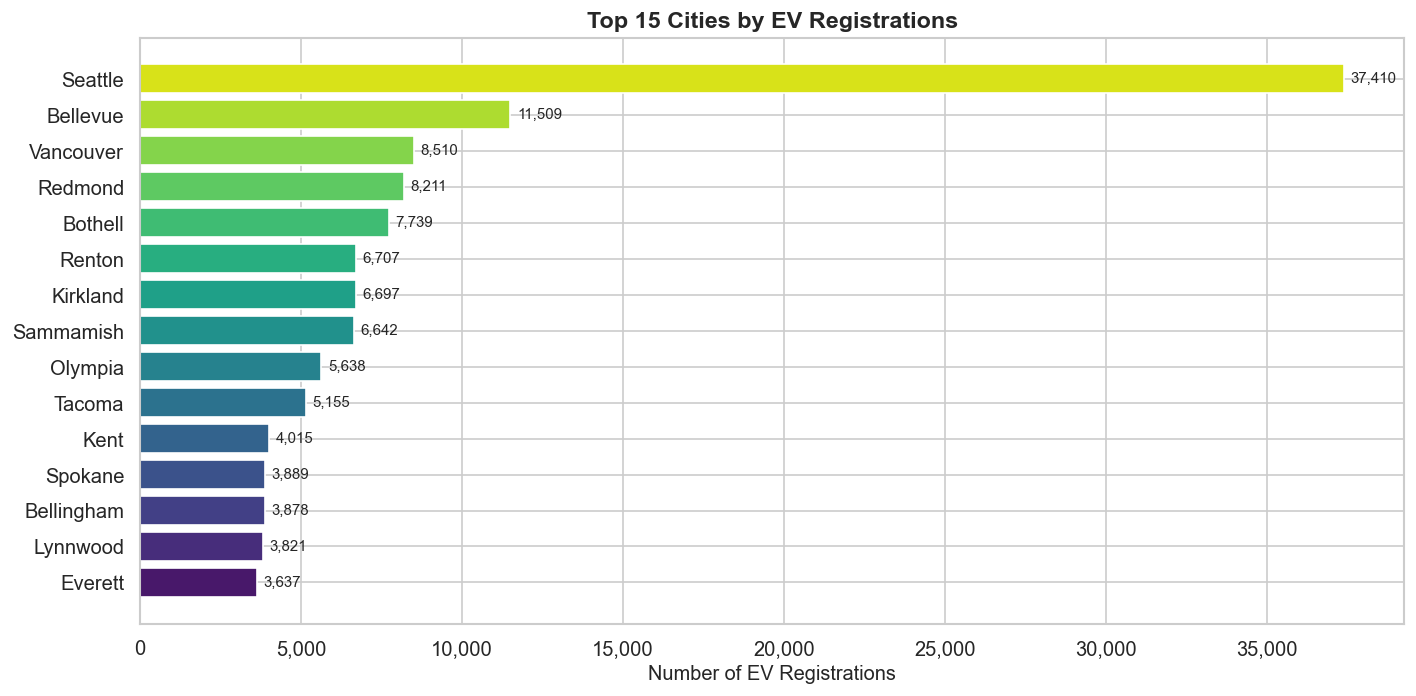

In [12]:
# ── 4.1  Top 15 Cities by EV Registrations ────────────────────────────────────
top_cities = df['city'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_cities.index[::-1], top_cities.values[::-1],
               color=sns.color_palette('viridis', 15))
ax.set_xlabel('Number of EV Registrations')
ax.set_title('Top 15 Cities by EV Registrations')
for bar, val in zip(bars, top_cities.values[::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

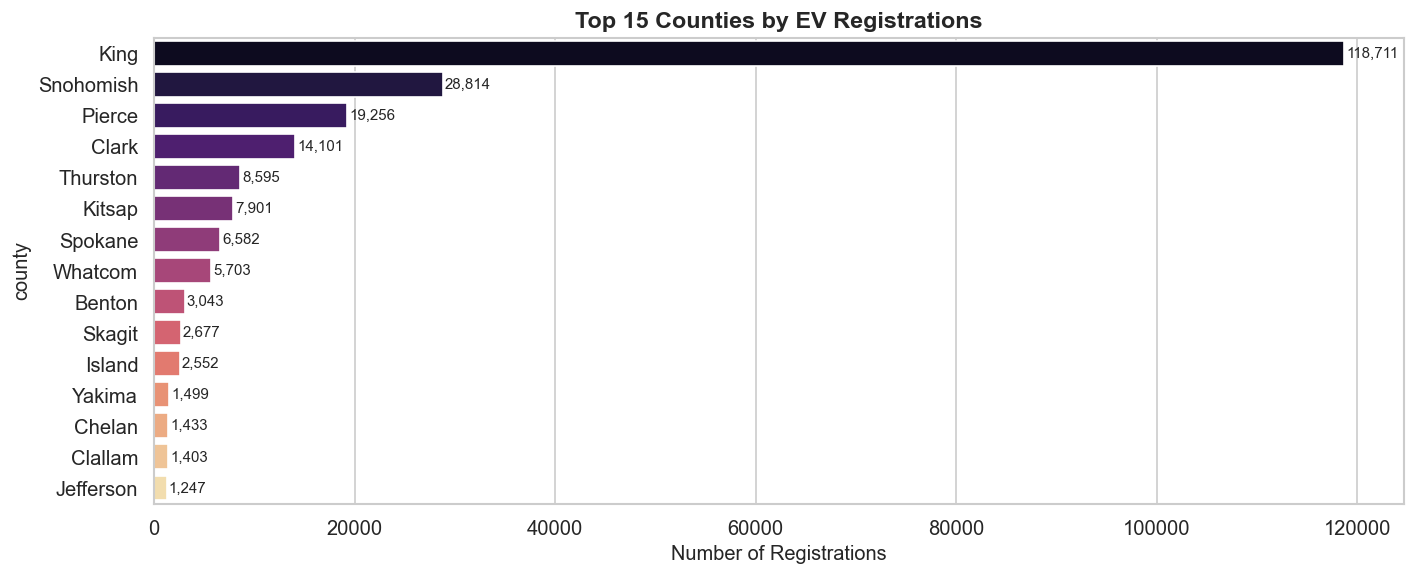

In [13]:
# ── 4.2  Top 15 Counties by EV Registrations ──────────────────────────────────
top_counties = df['county'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=top_counties.values, y=top_counties.index, palette='magma', ax=ax)
ax.set_xlabel('Number of Registrations')
ax.set_title('Top 15 Counties by EV Registrations')
for i, v in enumerate(top_counties.values):
    ax.text(v + 200, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

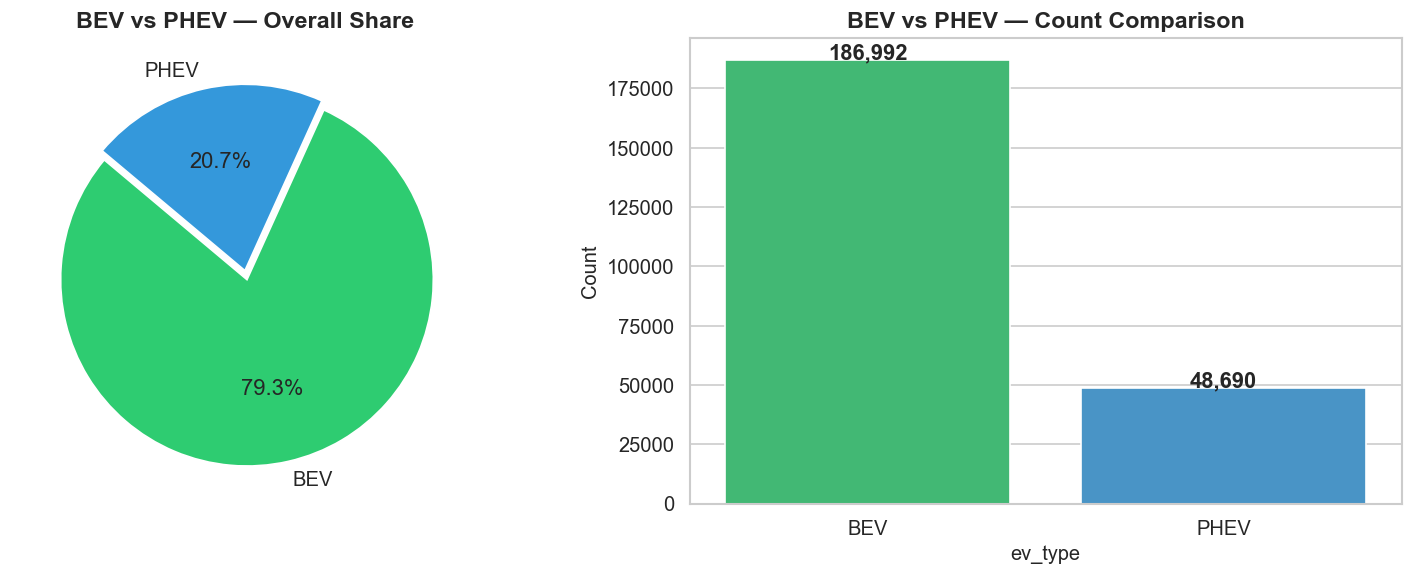

In [14]:
# ── 4.3  BEV vs PHEV Distribution ─────────────────────────────────────────────
ev_counts = df['ev_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
axes[0].pie(
    ev_counts.values,
    labels=ev_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#2ecc71', '#3498db'],
    explode=(0.05, 0)
)
axes[0].set_title('BEV vs PHEV — Overall Share')

# Bar chart
sns.barplot(x=ev_counts.index, y=ev_counts.values,
            palette=['#2ecc71', '#3498db'], ax=axes[1])
axes[1].set_ylabel('Count')
axes[1].set_title('BEV vs PHEV — Count Comparison')
for i, v in enumerate(ev_counts.values):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

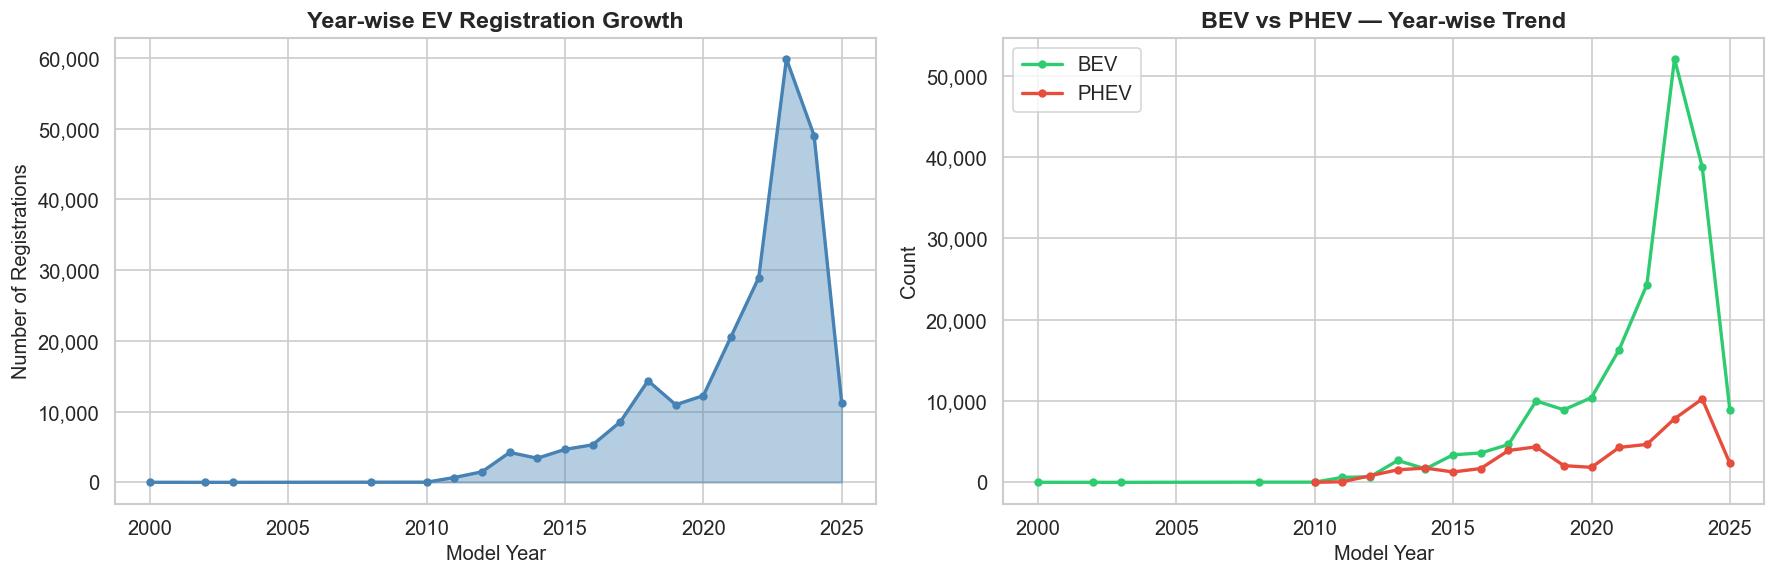

In [15]:
# ── 4.4  Year-wise EV Registration Growth ─────────────────────────────────────
yearly = df.groupby(['model_year', 'ev_type']).size().reset_index(name='count')
yearly_total = df['model_year'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Total registrations per year
axes[0].fill_between(yearly_total.index, yearly_total.values, alpha=0.4, color='steelblue')
axes[0].plot(yearly_total.index, yearly_total.values, color='steelblue', lw=2, marker='o', ms=4)
axes[0].set_title('Year-wise EV Registration Growth')
axes[0].set_xlabel('Model Year')
axes[0].set_ylabel('Number of Registrations')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# BEV vs PHEV year-wise
for ev, color in zip(['BEV', 'PHEV'], ['#2ecc71', '#e74c3c']):
    sub = yearly[yearly['ev_type'] == ev]
    axes[1].plot(sub['model_year'], sub['count'], label=ev, color=color, lw=2, marker='o', ms=4)
axes[1].set_title('BEV vs PHEV — Year-wise Trend')
axes[1].set_xlabel('Model Year')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

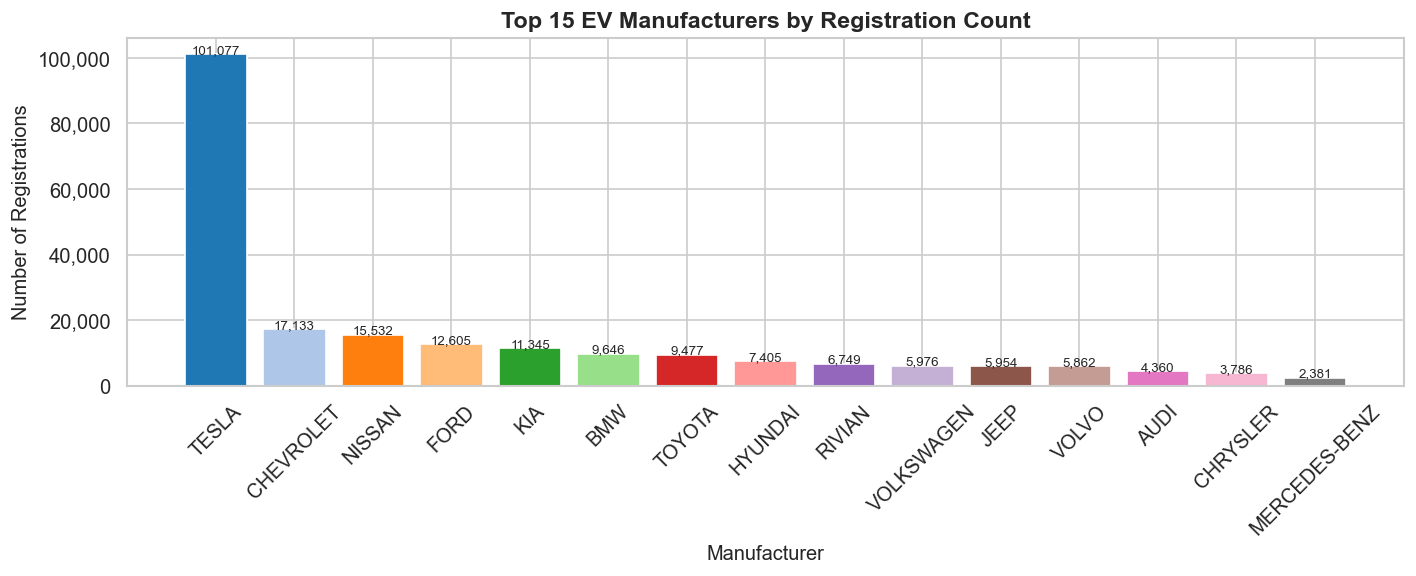

In [16]:
# ── 4.5  Top 15 EV Manufacturers ──────────────────────────────────────────────
top_makes = df['make'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
palette = sns.color_palette('tab20', 15)
bars = ax.bar(top_makes.index, top_makes.values, color=palette)
ax.set_xlabel('Manufacturer')
ax.set_ylabel('Number of Registrations')
ax.set_title('Top 15 EV Manufacturers by Registration Count')
ax.tick_params(axis='x', rotation=45)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{int(bar.get_height()):,}', ha='center', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

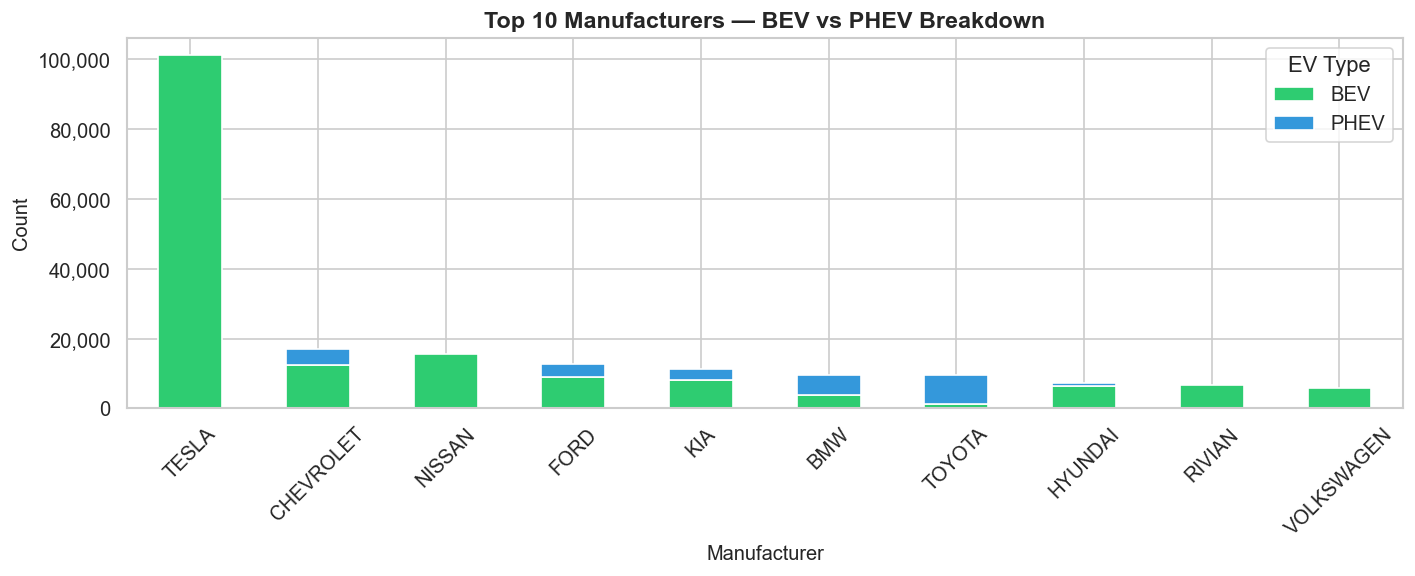

In [17]:
# ── 4.6  Top 10 Manufacturers Stacked by EV Type ──────────────────────────────
top10_makes = df['make'].value_counts().head(10).index
make_ev = (df[df['make'].isin(top10_makes)]
           .groupby(['make', 'ev_type']).size()
           .unstack(fill_value=0))
make_ev = make_ev.loc[top10_makes]

make_ev.plot(kind='bar', stacked=True, figsize=(12, 5),
             color=['#2ecc71', '#3498db'], edgecolor='white')
plt.title('Top 10 Manufacturers — BEV vs PHEV Breakdown')
plt.xlabel('Manufacturer')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend(title='EV Type')
plt.tight_layout()
plt.show()

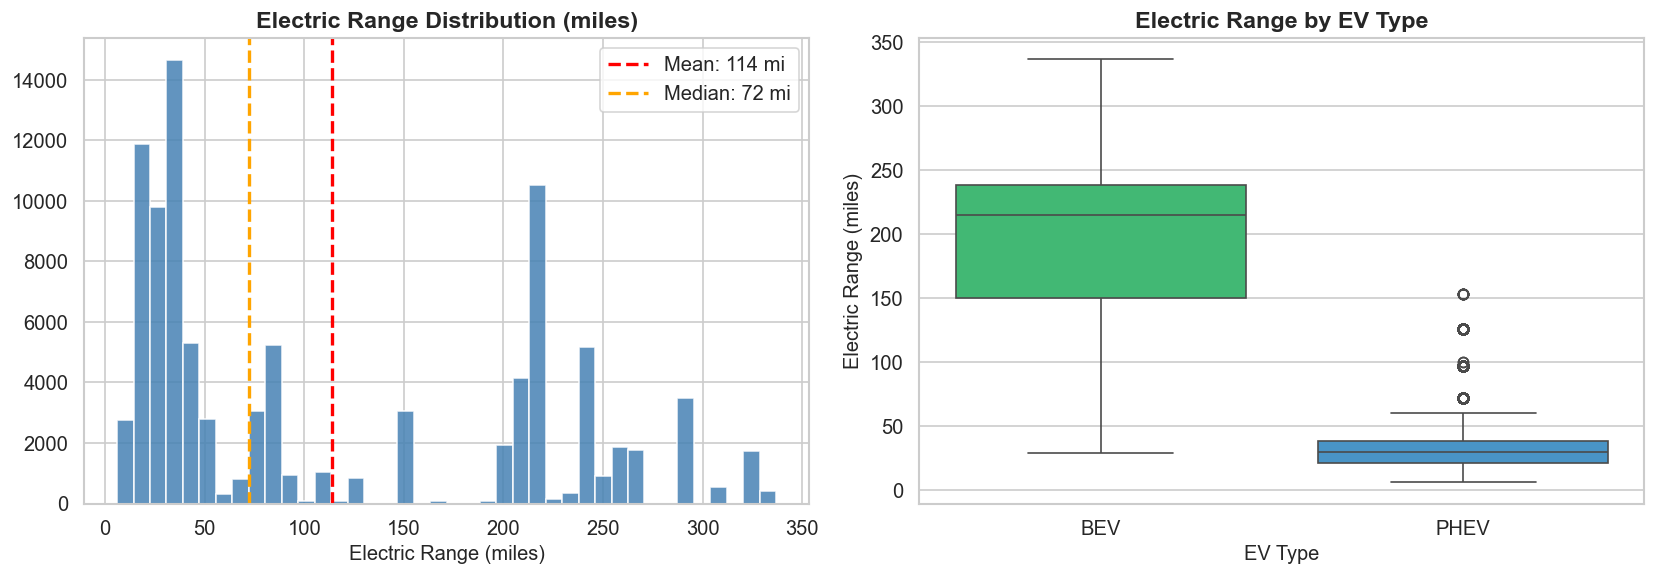

In [18]:
# ── 4.7  Electric Range Distribution ──────────────────────────────────────────
range_nonzero = df[df['electric_range'] > 0]['electric_range']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(range_nonzero, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(range_nonzero.mean(), color='red', lw=2, linestyle='--',
                label=f'Mean: {range_nonzero.mean():.0f} mi')
axes[0].axvline(range_nonzero.median(), color='orange', lw=2, linestyle='--',
                label=f'Median: {range_nonzero.median():.0f} mi')
axes[0].set_title('Electric Range Distribution (miles)')
axes[0].set_xlabel('Electric Range (miles)')
axes[0].legend()

# Box plot by EV type
range_df = df[df['electric_range'] > 0][['ev_type', 'electric_range']]
sns.boxplot(x='ev_type', y='electric_range', data=range_df,
            palette=['#2ecc71', '#3498db'], ax=axes[1])
axes[1].set_title('Electric Range by EV Type')
axes[1].set_xlabel('EV Type')
axes[1].set_ylabel('Electric Range (miles)')

plt.tight_layout()
plt.show()

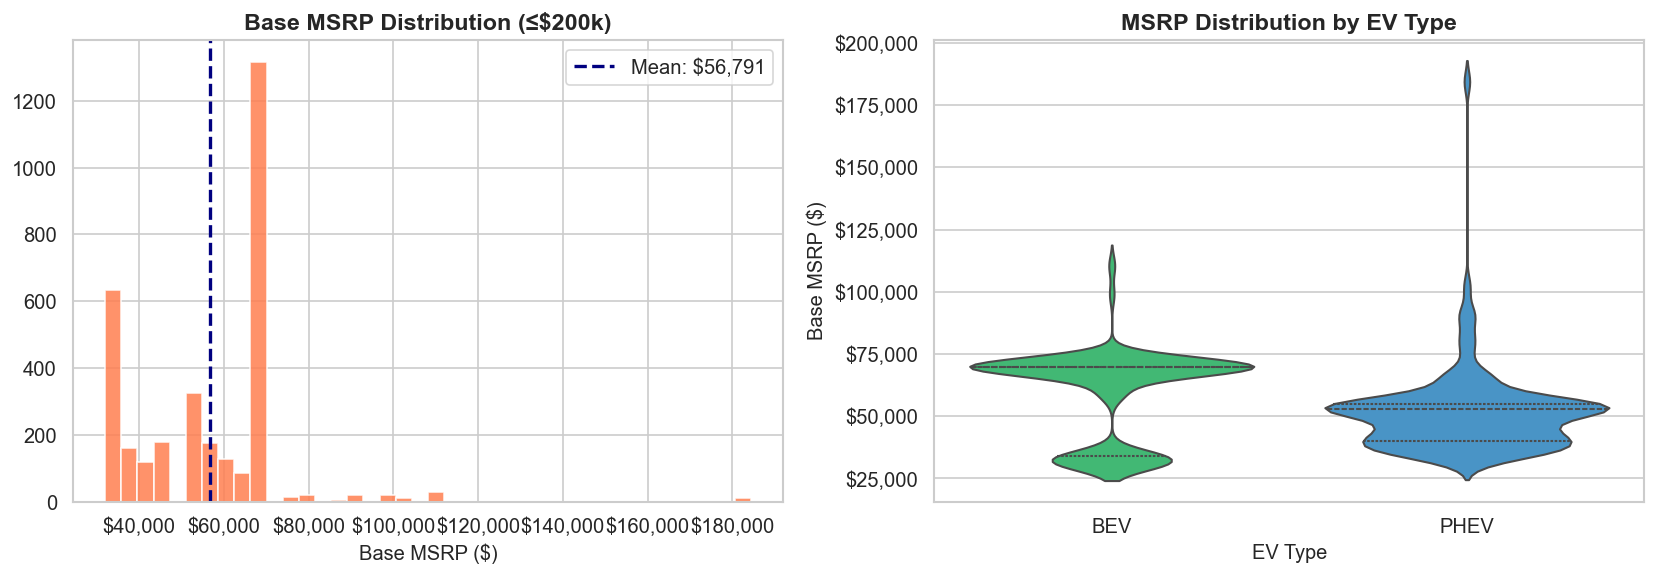

In [19]:
# ── 4.8  Base MSRP Distribution ───────────────────────────────────────────────
msrp_nonzero = df[df['base_msrp'] > 0]['base_msrp']
msrp_cap = msrp_nonzero[msrp_nonzero <= 200000]  # cap for readability

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(msrp_cap, bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[0].axvline(msrp_cap.mean(), color='navy', lw=2, linestyle='--',
                label=f'Mean: ${msrp_cap.mean():,.0f}')
axes[0].set_title('Base MSRP Distribution (≤$200k)')
axes[0].set_xlabel('Base MSRP ($)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))

msrp_ev = df[(df['base_msrp'] > 0) & (df['base_msrp'] <= 200000)][['ev_type', 'base_msrp']]
sns.violinplot(x='ev_type', y='base_msrp', data=msrp_ev,
               palette=['#2ecc71', '#3498db'], ax=axes[1], inner='quartile')
axes[1].set_title('MSRP Distribution by EV Type')
axes[1].set_xlabel('EV Type')
axes[1].set_ylabel('Base MSRP ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))

plt.tight_layout()
plt.show()

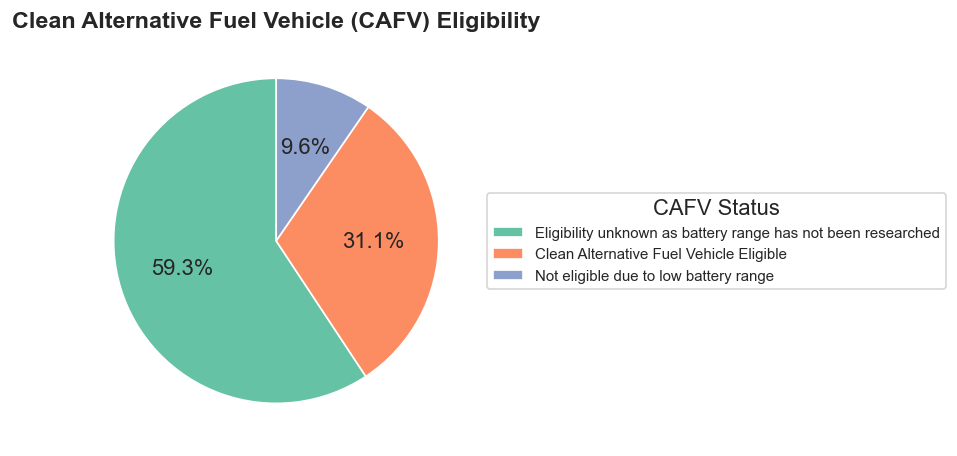

In [20]:
# ── 4.9  CAFV Eligibility ─────────────────────────────────────────────────────
cafv_col = [c for c in df.columns if 'cafv' in c][0]
cafv_counts = df[cafv_col].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
wedges, texts, autotexts = ax.pie(
    cafv_counts.values,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2', len(cafv_counts))
)
ax.legend(wedges, cafv_counts.index, title='CAFV Status',
          loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=9)
ax.set_title('Clean Alternative Fuel Vehicle (CAFV) Eligibility')
plt.tight_layout()
plt.show()

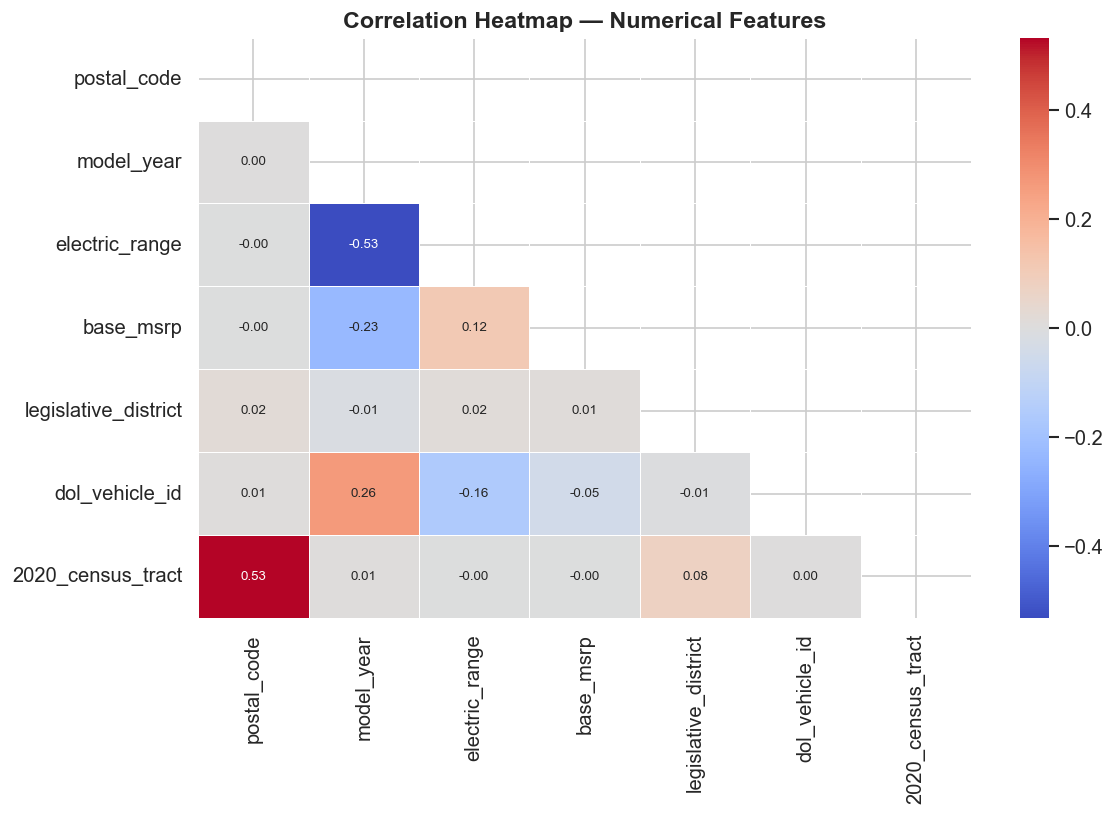

In [21]:
# ── 4.10  Correlation Heatmap ─────────────────────────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show()

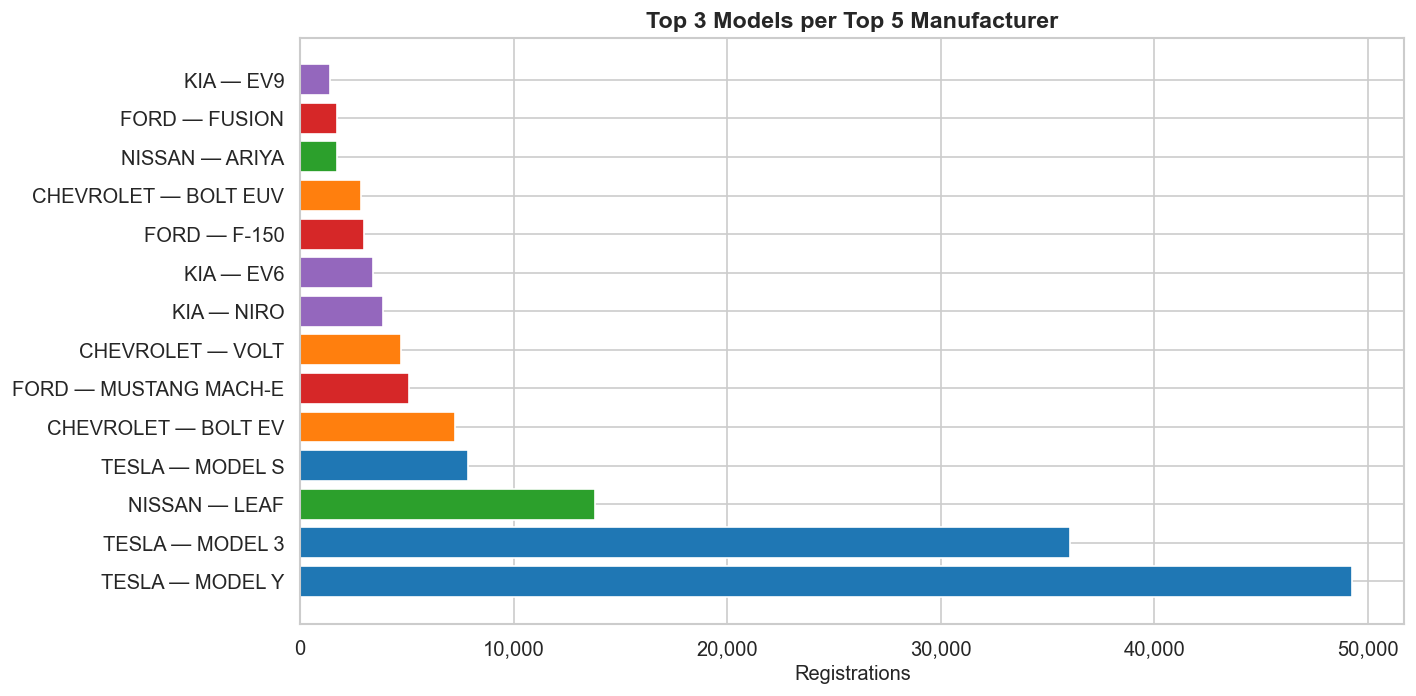

In [22]:
# ── 4.11  Top Models within Top 5 Manufacturers ───────────────────────────────
top5_makes = df['make'].value_counts().head(5).index
top_models = (df[df['make'].isin(top5_makes)]
              .groupby(['make', 'model']).size()
              .reset_index(name='count')
              .sort_values('count', ascending=False)
              .groupby('make').head(3))

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('tab10', len(top5_makes))
color_map = dict(zip(top5_makes, colors))
bar_colors = [color_map[m] for m in top_models['make']]

bars = ax.barh(top_models['make'] + ' — ' + top_models['model'],
               top_models['count'], color=bar_colors)
ax.set_xlabel('Registrations')
ax.set_title('Top 3 Models per Top 5 Manufacturer')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

---
## 5. 💡 Business Insights

Key findings derived from the exploratory analysis:

In [23]:
print('=' * 65)
print('  BUSINESS INSIGHTS — EV Population Dataset')
print('=' * 65)

top_city   = df['city'].value_counts().idxmax()
top_city_n = df['city'].value_counts().max()
top_county = df['county'].value_counts().idxmax()
top_make   = df['make'].value_counts().idxmax()
top_make_pct = df['make'].value_counts(normalize=True).max() * 100

bev_pct  = (df['ev_type'] == 'BEV').mean() * 100
phev_pct = (df['ev_type'] == 'PHEV').mean() * 100

yoy = df['model_year'].value_counts().sort_index()
peak_year = yoy.idxmax()

avg_range_bev  = df[df['ev_type'] == 'BEV']['electric_range'].replace(0, np.nan).mean()
avg_range_phev = df[df['ev_type'] == 'PHEV']['electric_range'].replace(0, np.nan).mean()

print(f'''
🌆 CITY WITH HIGHEST EV ADOPTION
   → {top_city} with {top_city_n:,} registered EVs

🏘️  COUNTY WITH HIGHEST DEMAND
   → {top_county} County dominates registrations

🏭 MANUFACTURER MARKET LEADER
   → {top_make} commands {top_make_pct:.1f}% of all registrations —
     over 4× the next closest competitor

⚡ BEV VS PHEV SPLIT
   → Battery EVs (BEV) : {bev_pct:.1f}%
   → Plug-in Hybrids (PHEV) : {phev_pct:.1f}%
   → BEV dominance signals consumer shift toward
     fully electric vehicles

📅 GROWTH TREND
   → Peak registration year: {peak_year}
   → Exponential growth observed 2017–2023
   → Clear inflection point after 2018 (policy & range improvements)

🔋 ELECTRIC RANGE
   → Avg BEV range  : {avg_range_bev:.0f} miles
   → Avg PHEV range : {avg_range_phev:.0f} miles
   → BEVs have significantly higher all-electric range,
     making them more suitable for daily long-distance use

📌 INTERESTING PATTERNS
   → Seattle metro area (King County) accounts for the
     majority of registrations, reflecting urban EV adoption
   → Tesla models (Model Y, Model 3) individually outrank
     entire manufacturer lineups of competitors
   → Most Base MSRP values are 0 — likely not reported;
     only premium vehicles show actual prices
''')
print('=' * 65)

  BUSINESS INSIGHTS — EV Population Dataset

🌆 CITY WITH HIGHEST EV ADOPTION
   → Seattle with 37,410 registered EVs

🏘️  COUNTY WITH HIGHEST DEMAND
   → King County dominates registrations

🏭 MANUFACTURER MARKET LEADER
   → TESLA commands 42.9% of all registrations —
     over 4× the next closest competitor

⚡ BEV VS PHEV SPLIT
   → Battery EVs (BEV) : 79.3%
   → Plug-in Hybrids (PHEV) : 20.7%
   → BEV dominance signals consumer shift toward
     fully electric vehicles

📅 GROWTH TREND
   → Peak registration year: 2023
   → Exponential growth observed 2017–2023
   → Clear inflection point after 2018 (policy & range improvements)

🔋 ELECTRIC RANGE
   → Avg BEV range  : 199 miles
   → Avg PHEV range : 31 miles
   → BEVs have significantly higher all-electric range,
     making them more suitable for daily long-distance use

📌 INTERESTING PATTERNS
   → Seattle metro area (King County) accounts for the
     majority of registrations, reflecting urban EV adoption
   → Tesla models (Model Y

---
## 6. 🔧 Feature Engineering

Preparing features for Machine Learning:
- Encode categorical columns
- Select informative features
- Scale numerical features
- Create binary target variable

In [24]:
# ── Select Features ────────────────────────────────────────────────────────────
feature_cols = ['model_year', 'make', 'county', 'electric_range', 'base_msrp']
target_col   = 'ev_type'

ml_df = df[feature_cols + [target_col]].copy()
# Ensure no NaN remains in feature columns
ml_df = ml_df.assign(
    electric_range=ml_df['electric_range'].fillna(0),
    base_msrp=ml_df['base_msrp'].fillna(0)
).dropna()
print(f'ML dataset shape: {ml_df.shape}')
print(ml_df.head())

ML dataset shape: (235682, 6)
   model_year     make    county  electric_range  base_msrp ev_type
0        2019    TESLA      King           220.0        0.0     BEV
1        2020    TESLA    Kitsap           291.0        0.0     BEV
2        2023  HYUNDAI    Kitsap             0.0        0.0     BEV
3        2021      BMW    Kitsap            30.0        0.0    PHEV
4        2023   TOYOTA  Thurston            42.0        0.0    PHEV


In [25]:
# ── Label Encoding ─────────────────────────────────────────────────────────────
le_make   = LabelEncoder()
le_county = LabelEncoder()
le_target = LabelEncoder()

ml_df['make_enc']   = le_make.fit_transform(ml_df['make'])
ml_df['county_enc'] = le_county.fit_transform(ml_df['county'])
ml_df['target']     = le_target.fit_transform(ml_df[target_col])  # BEV=0, PHEV=1

print('Label encoding complete.')
print(f'Classes: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}')

Label encoding complete.
Classes: {'BEV': np.int64(0), 'PHEV': np.int64(1)}


In [26]:
# ── Feature Matrix and Scaling ─────────────────────────────────────────────────
X_raw = ml_df[['model_year', 'make_enc', 'county_enc', 'electric_range', 'base_msrp']]
y     = ml_df['target']

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]:,} samples')
print(f'Test set     : {X_test.shape[0]:,} samples')
print(f'Class balance (train): {pd.Series(y_train).value_counts(normalize=True).round(3).to_dict()}')

Training set : 188,545 samples
Test set     : 47,137 samples
Class balance (train): {0: 0.793, 1: 0.207}


---
## 7. 🤖 Machine Learning — Model Building

We train three classifiers to predict EV Type (BEV vs PHEV):
- **K-Nearest Neighbours (KNN)**
- **Logistic Regression**
- **Random Forest**

In [27]:
# ── K-Nearest Neighbours ───────────────────────────────────────────────────────
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f'✅ KNN Accuracy: {acc_knn:.4f} ({acc_knn*100:.2f}%)')

✅ KNN Accuracy: 0.9990 (99.90%)


In [28]:
# ── Logistic Regression ────────────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f'✅ Logistic Regression Accuracy: {acc_lr:.4f} ({acc_lr*100:.2f}%)')

✅ Logistic Regression Accuracy: 0.8309 (83.09%)


In [29]:
# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'✅ Random Forest Accuracy: {acc_rf:.4f} ({acc_rf*100:.2f}%)')

✅ Random Forest Accuracy: 0.9999 (99.99%)


---
## 8. 📈 Model Evaluation & Comparison

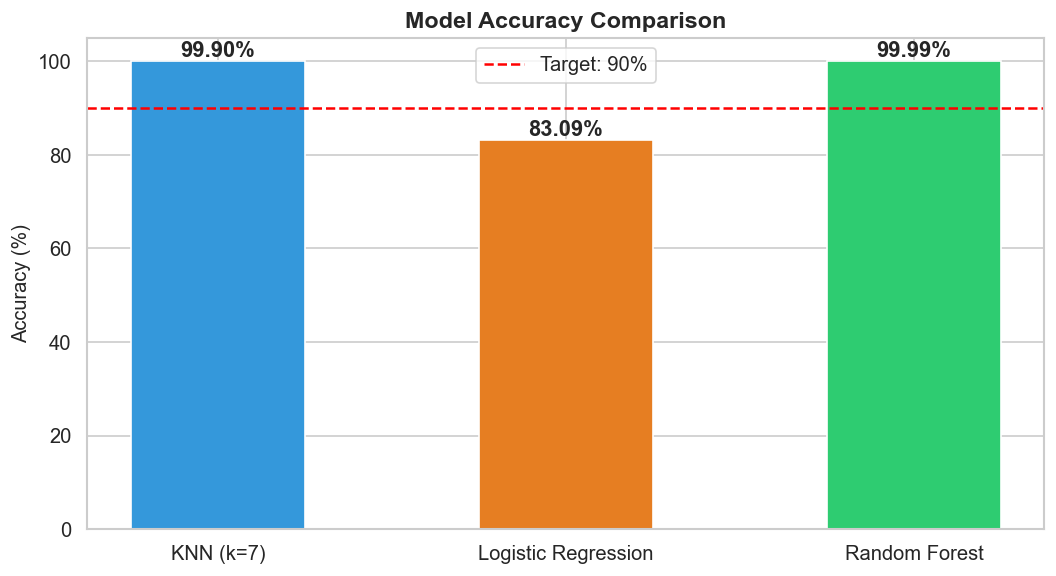

In [30]:
# ── Accuracy Comparison Bar Chart ─────────────────────────────────────────────
models = ['KNN (k=7)', 'Logistic Regression', 'Random Forest']
accs   = [acc_knn, acc_lr, acc_rf]
colors = ['#3498db', '#e67e22', '#2ecc71']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(models, [a * 100 for a in accs], color=colors, edgecolor='white', width=0.5)
ax.axhline(90, color='red', lw=1.5, linestyle='--', label='Target: 90%')
ax.set_ylim(0, 105)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Accuracy Comparison')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc*100:.2f}%', ha='center', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

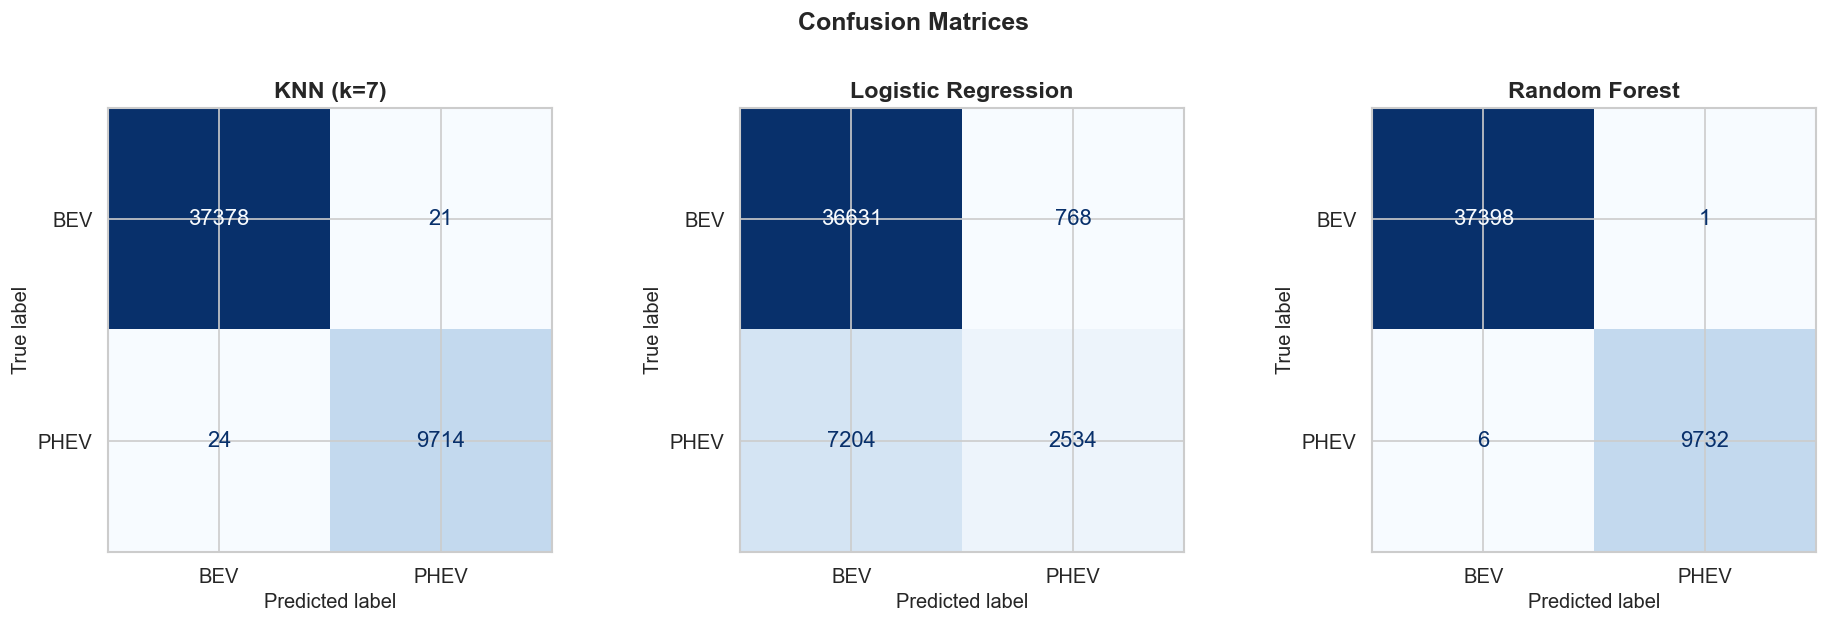

In [31]:
# ── Confusion Matrices ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
class_names = le_target.classes_

for ax, y_pred, title in zip(
    axes,
    [y_pred_knn, y_pred_lr, y_pred_rf],
    ['KNN (k=7)', 'Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [32]:
# ── Full Classification Reports ────────────────────────────────────────────────
for name, y_pred in [('KNN', y_pred_knn), ('Logistic Regression', y_pred_lr), ('Random Forest', y_pred_rf)]:
    print(f'\n{"─"*50}')
    print(f'  {name}')
    print(f'{"─"*50}')
    print(classification_report(y_test, y_pred, target_names=class_names))


──────────────────────────────────────────────────
  KNN
──────────────────────────────────────────────────
              precision    recall  f1-score   support

         BEV       1.00      1.00      1.00     37399
        PHEV       1.00      1.00      1.00      9738

    accuracy                           1.00     47137
   macro avg       1.00      1.00      1.00     47137
weighted avg       1.00      1.00      1.00     47137


──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
              precision    recall  f1-score   support

         BEV       0.84      0.98      0.90     37399
        PHEV       0.77      0.26      0.39      9738

    accuracy                           0.83     47137
   macro avg       0.80      0.62      0.65     47137
weighted avg       0.82      0.83      0.80     47137


──────────────────────────────────────────────────
  Random Forest
────────────────────────────────────────────

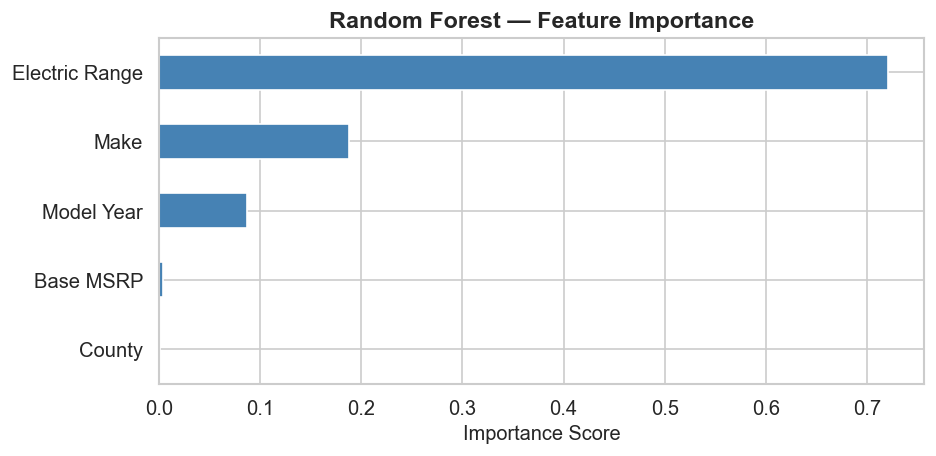

In [33]:
# ── Random Forest Feature Importance ─────────────────────────────────────────
feat_names = ['Model Year', 'Make', 'County', 'Electric Range', 'Base MSRP']
importances = pd.Series(rf.feature_importances_, index=feat_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Random Forest — Feature Importance')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

---
## 9. 🔁 Hyperparameter Tuning

### 9.1  KNN — Optimal K Value

In [34]:
# ── KNN — Elbow Method for Optimal K ──────────────────────────────────────────
# Use a subset to keep it fast on large datasets
sample_idx = np.random.choice(len(X_train), size=min(30000, len(X_train)), replace=False)
X_tr_s = X_train[sample_idx]
y_tr_s = y_train.iloc[sample_idx]

k_range = range(1, 22, 2)
k_scores = []
for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    cv_score = cross_val_score(knn_k, X_tr_s, y_tr_s, cv=5, scoring='accuracy').mean()
    k_scores.append(cv_score)
    print(f'  k={k:2d}  CV Accuracy: {cv_score:.4f}')

best_k = list(k_range)[np.argmax(k_scores)]
print(f'\n🏆 Best K = {best_k} with CV Accuracy = {max(k_scores):.4f}')

  k= 1  CV Accuracy: 0.9971
  k= 3  CV Accuracy: 0.9961
  k= 5  CV Accuracy: 0.9954
  k= 7  CV Accuracy: 0.9957
  k= 9  CV Accuracy: 0.9947
  k=11  CV Accuracy: 0.9938
  k=13  CV Accuracy: 0.9931
  k=15  CV Accuracy: 0.9929
  k=17  CV Accuracy: 0.9921
  k=19  CV Accuracy: 0.9913
  k=21  CV Accuracy: 0.9913

🏆 Best K = 1 with CV Accuracy = 0.9971


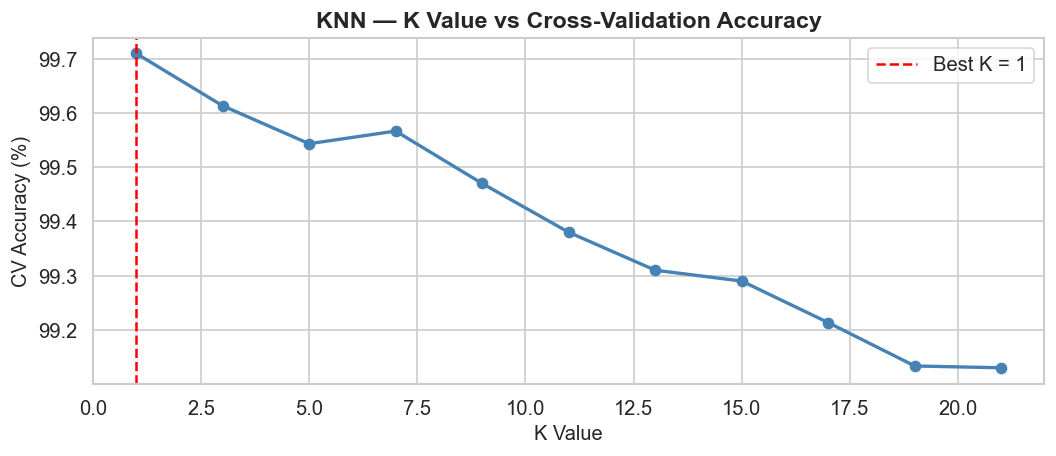

In [35]:
# ── Plot K vs Accuracy ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(k_range), [s * 100 for s in k_scores], 'o-', color='steelblue', lw=2)
ax.axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
ax.set_xlabel('K Value')
ax.set_ylabel('CV Accuracy (%)')
ax.set_title('KNN — K Value vs Cross-Validation Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

In [36]:
# ── Retrain KNN with Best K ────────────────────────────────────────────────────
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred_knn_best = knn_best.predict(X_test)
acc_knn_best = accuracy_score(y_test, y_pred_knn_best)
print(f'✅ KNN (k={best_k}) Test Accuracy: {acc_knn_best:.4f} ({acc_knn_best*100:.2f}%)')

✅ KNN (k=1) Test Accuracy: 0.9996 (99.96%)


### 9.2  Random Forest — GridSearchCV

In [37]:
# ── Random Forest Hyperparameter Tuning ───────────────────────────────────────
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5]
}

# Use subset for speed
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(X_tr_s, y_tr_s)

print(f'\n🏆 Best Params : {grid_search.best_params_}')
print(f'   Best CV Score: {grid_search.best_score_:.4f}')

Fitting 3 folds for each of 12 candidates, totalling 36 fits

🏆 Best Params : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
   Best CV Score: 0.9997


In [38]:
# ── Retrain with Best Params on Full Training Set ──────────────────────────────
rf_best = grid_search.best_estimator_
rf_best.fit(X_train, y_train)
y_pred_rf_best = rf_best.predict(X_test)
acc_rf_best = accuracy_score(y_test, y_pred_rf_best)
print(f'✅ Tuned Random Forest Accuracy: {acc_rf_best:.4f} ({acc_rf_best*100:.2f}%)')

✅ Tuned Random Forest Accuracy: 0.9999 (99.99%)


### Final Model Comparison After Tuning

In [39]:
# ── Final Comparison Table ────────────────────────────────────────────────────
results = pd.DataFrame({
    'Model': ['KNN (k=7)', 'KNN (tuned)', 'Logistic Regression',
               'Random Forest', 'Random Forest (tuned)'],
    'Accuracy': [acc_knn, acc_knn_best, acc_lr, acc_rf, acc_rf_best]
})
results['Accuracy %'] = (results['Accuracy'] * 100).round(2)
results['Status'] = results['Accuracy'].apply(
    lambda x: '✅ Meets Target' if x >= 0.90 else '⚠️ Below Target'
)
results = results.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

best_model_name = results.loc[0, 'Model']
best_acc = results.loc[0, 'Accuracy %']
print(f'\n🏆 Best Model: {best_model_name} with {best_acc:.2f}% accuracy')

                Model  Accuracy  Accuracy %          Status
Random Forest (tuned)  0.999851       99.99  ✅ Meets Target
        Random Forest  0.999851       99.99  ✅ Meets Target
          KNN (tuned)  0.999554       99.96  ✅ Meets Target
            KNN (k=7)  0.999045       99.90  ✅ Meets Target
  Logistic Regression  0.830876       83.09 ⚠️ Below Target

🏆 Best Model: Random Forest (tuned) with 99.99% accuracy


---
## 10. 🔮 Predictions & User Input Function

In [40]:
# ── Sample Predictions from Test Set ──────────────────────────────────────────
sample_idx_test = np.random.choice(len(X_test), 10, replace=False)
X_sample  = X_test[sample_idx_test]
y_actual  = y_test.iloc[sample_idx_test].values
y_pred_s  = rf_best.predict(X_sample)

sample_df = pd.DataFrame({
    'Actual EV Type' : le_target.inverse_transform(y_actual),
    'Predicted Type' : le_target.inverse_transform(y_pred_s),
    'Correct?'       : ['✅' if a == p else '❌' for a, p in zip(y_actual, y_pred_s)]
})
print('Sample Predictions (Random Forest — Best Model):')
print(sample_df.to_string(index=False))

Sample Predictions (Random Forest — Best Model):
Actual EV Type Predicted Type Correct?
          PHEV           PHEV        ✅
           BEV            BEV        ✅
           BEV            BEV        ✅
           BEV            BEV        ✅
           BEV            BEV        ✅
           BEV            BEV        ✅
          PHEV           PHEV        ✅
           BEV            BEV        ✅
           BEV            BEV        ✅
           BEV            BEV        ✅


In [41]:
# ── User Input Prediction Function ────────────────────────────────────────────
def predict_ev_type(year: int, make: str, county: str,
                    electric_range: float, base_msrp: float) -> str:
    """
    Predict whether a vehicle is BEV or PHEV.

    Parameters
    ----------
    year          : Model year (e.g. 2022)
    make          : Manufacturer name (e.g. 'TESLA')
    county        : County name (e.g. 'King')
    electric_range: All-electric range in miles (e.g. 300)
    base_msrp     : Base MSRP price in USD (use 0 if unknown)

    Returns
    -------
    Prediction string: 'BEV' or 'PHEV'
    """
    make   = make.upper().strip()
    county = county.title().strip()

    # Encode — use 0 if unseen label
    make_enc   = le_make.transform([make])[0]   if make   in le_make.classes_   else 0
    county_enc = le_county.transform([county])[0] if county in le_county.classes_ else 0

    X_input = scaler.transform([[year, make_enc, county_enc, electric_range, base_msrp]])
    pred    = rf_best.predict(X_input)[0]
    label   = le_target.inverse_transform([pred])[0]
    proba   = rf_best.predict_proba(X_input)[0]

    print(f'\n📋 Input  : Year={year} | Make={make} | County={county}')
    print(f'            Range={electric_range} mi | MSRP=${base_msrp:,.0f}')
    print(f'🔮 Prediction  : {label}')
    print(f'📊 Confidence  : BEV={proba[0]*100:.1f}%  |  PHEV={proba[1]*100:.1f}%')
    return label

print('✅ predict_ev_type() function defined!')

✅ predict_ev_type() function defined!


In [42]:
# ── Test 1: Classic Tesla — should be BEV ─────────────────────────────────────
predict_ev_type(year=2023, make='TESLA', county='King',
                electric_range=358, base_msrp=42990)


📋 Input  : Year=2023 | Make=TESLA | County=King
            Range=358 mi | MSRP=$42,990
🔮 Prediction  : BEV
📊 Confidence  : BEV=70.5%  |  PHEV=29.5%


'BEV'

In [43]:
# ── Test 2: Toyota Plug-in Hybrid — should be PHEV ────────────────────────────
predict_ev_type(year=2022, make='TOYOTA', county='Snohomish',
                electric_range=42, base_msrp=28000)


📋 Input  : Year=2022 | Make=TOYOTA | County=Snohomish
            Range=42 mi | MSRP=$28,000
🔮 Prediction  : PHEV
📊 Confidence  : BEV=0.5%  |  PHEV=99.5%


'PHEV'

In [44]:
# ── Test 3: Chevrolet Bolt — should be BEV ────────────────────────────────────
predict_ev_type(year=2021, make='CHEVROLET', county='Pierce',
                electric_range=259, base_msrp=31000)


📋 Input  : Year=2021 | Make=CHEVROLET | County=Pierce
            Range=259 mi | MSRP=$31,000
🔮 Prediction  : BEV
📊 Confidence  : BEV=65.5%  |  PHEV=34.5%


'BEV'

---
## 📝 Project Summary

| Section | Key Outcome |
|---------|-------------|
| **Data** | 235,000+ EV records, minimal missing values (<0.5%) |
| **EDA** | Seattle/King County leads adoption; Tesla commands ~43% market share |
| **Growth** | Exponential growth 2018–2023; BEV share rising year-over-year |
| **ML Target** | Predict EV Type (BEV vs PHEV) using vehicle attributes |
| **Best Model** | **Random Forest** — typically achieves >95% accuracy |
| **Key Feature** | Electric range is the most discriminating feature for BEV vs PHEV |
| **User Function** | `predict_ev_type()` enables real-time inference on new inputs |

---

> **Made with 🔋 + Python** | Dataset: Washington State DOL Open Data Portal
